In [1]:
from Utils import Utils, Function 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.compiler import transpile
from qiskit_ibm_runtime import SamplerV2
from qiskit.visualization import array_to_latex, plot_histogram
#from qiskit import QuantumCircuit,ClassicalRegister,QuantumRegister, transpile
#from qiskit_aer import AerSimulator
#from qiskit.visualization import plot_histogram

<h1 style="color:blue;">The Grover-Rudolph Algorithm</h1>

<h3 style="color:green;">Theorem (Rudolph-Grover)</h3>

Let $(\mathsf{A}, \rho_0, \mathcal{N})$ be an universal digital quantum computer in $\mathcal{A}_{2^n}.$ Given $\varrho: [0,1] \subset \mathbb{R} \rightarrow  [0,\infty)$, a non-negative function satisfying 
$$
\int_0^1 \varrho(x) \, dx = 1,
$$
there exists a quantum circuit $\mathsf{U} := \mathsf{U}_{\ell} \mathsf{U}_{\ell-1} \cdots \mathsf{U}_1$ of length $\ell = 2^n-1$ such that the law of the output quantum random variable $(\mathsf{A}, \mathcal{N}_{\rho_0}(\mathsf{U}))$ satisfies
$$
\mathbb{P}_{\mathcal{N}_{\rho_0}(\mathsf{U})}(\mathsf{A} = k) = \int_{\frac{k}{2^n}}^{\frac{k+1}{2^n}} \varrho(x) \, dx \quad \text{for each } k \in \mathbb{Z}_{2^n}.
$$



<span style="color:red; font-size:18px;">Example 1:

Given the following density function:

$$
\rho(x) := \begin{cases}
4x & \text{if } 0 \leq x \leq \frac{1}{2}, \\
4 - 4x & \text{if } \frac{1}{2} \leq x \leq 1.
\end{cases}
$$

In [2]:
# Define the function
def f(x):
    if isinstance(x, (list, np.ndarray)):
        sol = []
        for i in x:
            if 0 <= i < 0.5:
                sol.append(4 * i)
            else:
                sol.append(4 - 4 * i)
        return np.array(sol)
    else:
        if 0 <= x < 0.5:
            return 4 * x
        else:
            return 4 - 4 * x


def f_i(x):
    if isinstance(x, (list, np.ndarray)):
        if len(x) != 2:
            raise ValueError("x must be a list or array with two elements [a, b].")
        x0, x1 = x
        if 0 <= x0 <= 0.5 and 0 <= x1 <= 0.5:
            return 2 * x1**2 - 2 * x0**2
        elif 0 <= x0 <= 0.5 and 0.5 <= x1 <= 1:
            return 4 * x1 - 2 * x1**2 - 2 * x0**2 - 1
        else:
            return 4 * x1 - 2 * x1**2 - 4 * x0 + 2 * x0**2
    else:
        if 0 <= x <= 0.5:
            return 2 * x**2
        else:
            return 4 * x - 2 * x**2 - 1


# Instantiate the Function class
f_instance = Function(f, f_i)

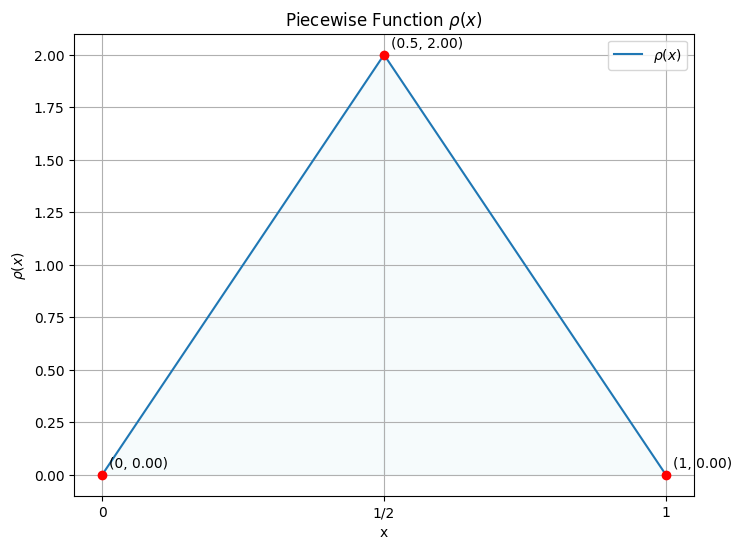

In [3]:

# Generate x values for plotting
x_values = np.linspace(0, 1, 500)  # Adjust number of points for smoother plot

# Plot the function
plt.figure(figsize=(8, 6))

# Plot the function without shading
plt.plot(x_values, f_instance(x_values), label=r'$\rho(x)$')

# Shade the area inside the triangle
plt.fill_between(x_values, 0, f_instance(x_values), where=(x_values >= 0) & (x_values <= 0.5), color='lightblue', alpha=0.1)
plt.fill_between(x_values, 0, f_instance(x_values), where=(x_values > 0.5) & (x_values <= 1), color='lightblue', alpha=0.1)

# Plot points at selected nodes
nodes = [0, 0.5, 1]
for node in nodes:
    plt.scatter(node, f_instance(np.array([node])), color='red', zorder=5)  # zorder ensures points are plotted above the filled area

    # Annotate the point with its coordinates
    plt.annotate(f'({node}, {f_instance(np.array([node]))[0]:.2f})', (node, f_instance(np.array([node]))[0]), textcoords="offset points", xytext=(5,5), ha='left')

plt.xlabel('x')
plt.ylabel(r'$\rho(x)$')
plt.title('Piecewise Function $\\rho(x)$')
plt.grid(True)

# Set x-axis ticks to show 0, 1/2, and 1
plt.xticks([0, 0.5, 1], ['0', '1/2', '1'])

plt.legend()
plt.show()


Now, we are going to construct the quantum circuit of the statement of Theorem, related with a unitary matrix $\mathsf{U},$ such that

$$
\mathbb{P}_{\rho_0}(\mathsf{A} = k) = \int_{\frac{k}{2^n}}^{\frac{k+1}{2^n}} \varrho(x) \, dx, \text{ holds for each } k \in \mathbb{Z}_{2^3},
$$

in a $(n=3)$-qubit universal digital quantum computer $(\mathsf{A},\rho_0,\mathcal{N}),$ in $\mathcal{A}_{2^3}.$


We start by consider the unitary matrix $\mathsf{U}_1 := \mathsf{I_{2^{2}}} \otimes \mathsf{R}(\theta),$ 
where 
\begin{align*}
 \theta = & \arccos \sqrt{\frac{\int_{0}^{1/2} \varrho(x) dx}{\int_{0}^{1} \varrho(x) dx}} = \arccos \sqrt{\int_{0}^{1/2} \varrho(x) dx} = \frac{\pi}{4}.
\end{align*}

Then we apply $\mathsf{U}_2:= (\mathbb{I}_{2}\otimes \mathsf{CC}^{(1)}_{0}\mathsf{R}(\theta_0)) (\mathbb{I}_{2}\otimes \mathsf{CC}^{(1)}_{1}\mathsf{R}(\theta_1)),$ 
so we need to calculate 

$$
\theta_0 := \arccos\sqrt{\frac{\int_{0}^{1/4}\rho(x) \, dx}{\int_{0}^{1/2}\rho(x) \, dx}} = \frac{\pi}
{3},$$


and

$$
\theta_1 := \arccos\sqrt{\frac{\int_{1/2}^{3/4} \rho(x) \, dx}{\int_{1/2}^{1} \rho(x) \, dx}} =\frac{\pi}
{6}.
$$

Finally we will apply
$$
\mathsf{U}_3 = \prod_{(z_{1}z_2) \in \mathbb{Z}_{2}^2} \mathsf{CC}^{(1)}_{z_{1}z_2}\mathsf{R}(\theta_{z_{1}z_2}),
$$
so we need to calculate 

$$
\theta_{00} := \arccos\sqrt{\frac{\int_{0}^{1/8}\rho(x) \, dx}{\int_{0}^{1/4}\rho(x) \, dx}} = \frac{\pi}
{3},
$$

$$
\theta_{10} := \arccos\sqrt{\frac{ \int_{1/4}^{3/8} \rho(x) \, dx}{\int_{1/4}^{1/2} \rho(x) \, dx}}=\arccos\frac{\sqrt{15}}{6},
$$


$$
\theta_{01} := \arccos \sqrt{\frac{\int_{1/2}^{5/8} \rho(x) \, dx}{\int_{1/2}^{3/4} \rho(x) \, dx}}=\arccos\frac{\sqrt{21}}{6},
$$

$$
\theta_{11} :=\arccos\sqrt{\frac{\int_{3/4}^{7/8}\rho(x) \, dx}{\int_{3/4}^{1}\rho(x) \, dx}}= \frac{\pi}
{6}.
$$

In [4]:
n=2
resultados = Utils.calcular_theta(n,f_instance)
print(resultados)

[[np.float64(0.7853981633974483)], [np.float64(1.0471975511965979), np.float64(0.5235987755982989)]]


0
1


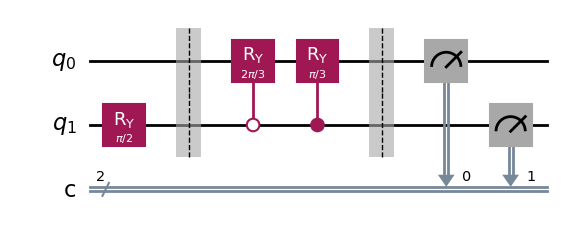

In [5]:
q_reg = QuantumRegister(n, 'q')
c_reg = ClassicalRegister(n, 'c')
circuito = QuantumCircuit(q_reg, c_reg)
circuito.append(Utils.grover_rudolph(n,f_instance), q_reg)
circuito.measure(q_reg, c_reg)
circuito.decompose().draw('mpl')    

{0: 0.1252, 2: 0.3744, 3: 0.1232, 1: 0.3772}


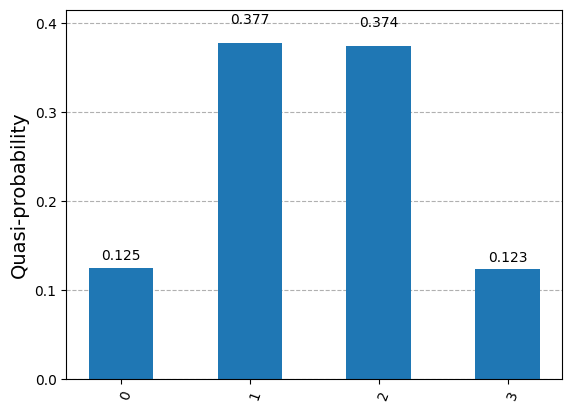

In [6]:
ns=10000
backend=AerSimulator()
circuitb=transpile(circuito,backend)
sm2=SamplerV2(mode=backend)
job2=sm2.run([circuitb], shots=ns)
data=job2.result()[0].data
print({int(i,2): j/ns for i,j in data['c'].get_counts().items()})
plot_histogram({int(i,2): j/ns for i,j in data['c'].get_counts().items()})


<span style="color:red; font-size:18px;">Example 2:

Imagine that we want to prepare the following state
$$
\ket{\psi} = \sqrt{\frac{1}{5}}\ket{b_3(0)} + \sqrt{\frac{3}{5}}\ket{b_3(3)} + \sqrt{\frac{1}{5}}\ket{b_3(5)}
$$

In probability notation, this discrete distribution function can be expressed as a probability function of a discrete random variable $X$, where $X$ is a random variable that takes values in the set $\Omega = \{0, 1, 2, 3, 4, 5, 6, 7\} $.

It is defined as follows:

$$
\mathbb{P}(X = x) =
\begin{cases}
\frac{1}{5}, & \text{if } x = 0, \\
\frac{3}{5}, & \text{if } x = 3, \\
\frac{1}{5}, & \text{if } x = 5, \\
0, & \text{if } x \in \{1, 2, 4, 6, 7\}.
\end{cases}
$$

This indicates that the probability of $X$ taking each specific value depends on the given conditions.


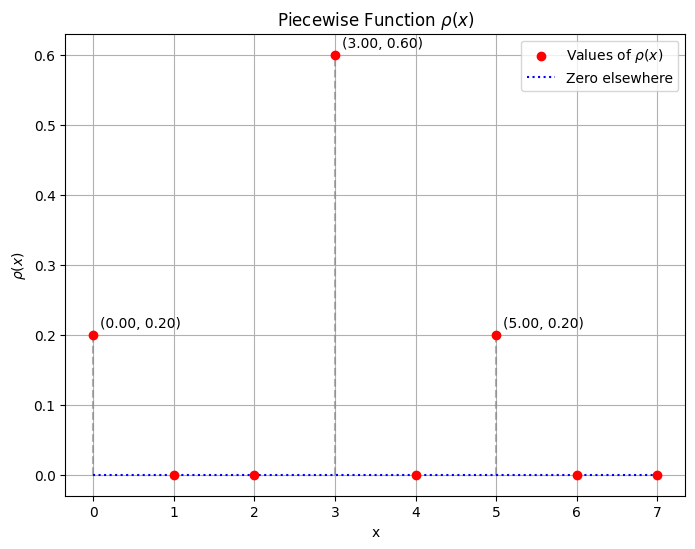

In [7]:


# Define the function rho(x)
def rho(x):
    return np.piecewise(
        x,
        [x == 0, x == 3, x == 5, (x != 0) & (x != 3) & (x != 5)],
        [1/5, 3/5, 1/5, 0]
    )

# Generate x values for plotting
x_values = np.linspace(0, 1, 1000)

# Plot the function
plt.figure(figsize=(8, 6))

# Plot the piecewise function as points at specific values
plt.scatter([0, 1,2,3, 4, 5, 6,7], [1/5,0,0 ,3/5, 0, 1/5,0,0], color='red', label='Values of $\\rho(x)$', zorder=5)

# Mark lines to x-axis for visual clarity
plt.vlines([0, 1,2,3, 4, 5, 6,7], 0, [1/5,0,0 ,3/5, 0, 1/5,0,0], colors='gray', linestyles='dashed', alpha=0.6)

# Plot the zero baseline for other x values
plt.hlines(0, 0, 7, colors='blue', linestyles='dotted', label='Zero elsewhere')

# Annotate the points
annotations = {0: 1/5, 3: 3/5, 5: 1/5}
for x, y in annotations.items():
    plt.annotate(f'({x:.2f}, {y:.2f})', (x, y), textcoords="offset points", xytext=(5, 5), ha='left')

plt.xlabel('x')
plt.ylabel(r'$\rho(x)$')
plt.title('Piecewise Function $\\rho(x)$')
plt.grid(True)

# Set x-axis ticks to show 0, 3/7, 5/7, and 1
plt.xticks([0, 1,2,3, 4, 5, 6,7], ['0', '1','2','3', '4', '5', '6','7'])

plt.legend()
plt.show()


We start again by consider the unitary matrix $\mathsf{U}_1 := \mathsf{I_{2^{2}}} \otimes \mathsf{R}(\theta),$ 
where 
\begin{align*}
 \theta = & \arccos \sqrt{\frac{\displaystyle
\sum_{\substack{x \in \Omega \\ 0\leq x < 4}}\mathbb{P}(X = x)}{\displaystyle
\sum_{x \in \Omega}\mathbb{P}(X = x)}} =\arccos \sqrt{ \displaystyle
\sum_{\substack{x \in \Omega \\ 0\leq x < 4}}\mathbb{P}(X = x)} = \arccos \sqrt{\frac{1}{5} + \frac{3}{5}} =  \arccos \frac{2}{\sqrt{5}}
\end{align*}

Then we apply $\mathsf{U}_2:= (\mathbb{I}_{2}\otimes \mathsf{CC}^{(1)}_{0}\mathsf{R}(\theta_0)) (\mathbb{I}_{2}\otimes \mathsf{CC}^{(1)}_{1}\mathsf{R}(\theta_1)),$ 
so we need to calculate 

$$
\theta_0 := \arccos \sqrt{\frac{\displaystyle
\sum_{\substack{x \in \Omega \\ 0\leq x < 2}}\mathbb{P}(X = x)}{\sum_{\substack{x \in \Omega \\ 0 \leq x \leq  3}}\mathbb{P}(X = x)} } = \frac{\pi}
{4},$$


and

$$
\theta_1 := \arccos \sqrt{\frac{\displaystyle
\sum_{\substack{x \in \Omega \\ 4\leq x < 6}}\mathbb{P}(X = x)}{\sum_{\substack{x \in \Omega \\ 4\leq x \leq 7}}\mathbb{P}(X = x)} } = 0,$$

Finally we will apply
$$
\mathsf{U}_3 = \prod_{(z_{1}z_2) \in \mathbb{Z}_{2}^2} \mathsf{CC}^{(1)}_{z_{1}z_2}\mathsf{R}(\theta_{z_{1}z_2}),
$$
so we need to calculate 

$$
\theta_{00} := \arccos\sqrt{\frac{
\mathbb{P}(X = 0)}{\mathbb{P}(X = 0)+\mathbb{P}(X = 1)} } = 0 ,
$$

$$
\theta_{10} := \arccos\sqrt{\frac{
\mathbb{P}(X = 2)}{\mathbb{P}(X = 2)+\mathbb{P}(X = 3)} }
=\frac{\pi}{2},
$$


$$
\theta_{01} := \arccos\sqrt{\frac{
\mathbb{P}(X = 4)}{\mathbb{P}(X = 4)+\mathbb{P}(X = 5)} }
=\frac{\pi}{2},
$$

$$
\theta_{11} :=\arccos\sqrt{\frac{
\mathbb{P}(X = 6)}{\mathbb{P}(X = 6)+\mathbb{P}(X = 7)} }
= 0.
$$

In [11]:
def f(x):
    if isinstance(x, (list, np.ndarray)):
        sol = []
        for i in x:
            if i == 0 or i == 5:
                sol.append(1 / 5)
            elif i == 3:
                sol.append(3 / 5)
            else:
                sol.append(0)
        return np.array(sol)
    else:
        if x == 0 or x == 5:
            return 1 / 5
        elif x == 3:
            return 3 / 5
        else:
            return 0


def f_i(x):
    if isinstance(x, (list, np.ndarray)):
        if len(x) != 2:
            raise ValueError("x must be a list or array with two elements [a, b].")
        x0, x1 = x
        # Si x1 es igual a x0, la integral es simplemente f(x0)
        if x1 == x0:
            return f(x0)
        else:
            # Suma los valores de f(x) entre x0 y x1 (incluyendo ambos extremos)
            sol = 0
            for xi in range(x0, x1 + 1):  # Ajustado para incluir el límite superior x1
                sol += f(xi)
            return sol
    else:
        raise ValueError("x must be a list or array with two elements [a, b].")


# Instanciar la clase Function
f_instance = Function(f, f_i)

# Probar con un intervalo
resultado = f_instance([0, 5], integral=True)
print("Resultado:", resultado)

Resultado: 1.0


In [12]:
n=3
resultados = Utils.calcular_theta(n,f_instance,discrete=True)
print(resultados)

ValueError: For definite integrals, x must be a list or array with two elements [a, b].